!pip install pandas numpy matplotlib seaborn scikit-learn requests

In [30]:
import pandas as pd
import numpy as np

import requests
from zipfile import ZipFile
from io import BytesIO

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

Step 1 — Download & Load the Data

In [31]:
url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"

response = requests.get(url, timeout=60)
response.raise_for_status()

zip_file = ZipFile(BytesIO(response.content))

ratings = pd.read_csv(zip_file.open("ml-latest-small/ratings.csv"))
movies = pd.read_csv(zip_file.open("ml-latest-small/movies.csv"))

<div dir="rtl" style="text-align:right">

הצגת 5 שורות ראשונות
<div>

In [32]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [33]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


<div dir="rtl" style="text-align:right">

בדיקה ראשונית של הנתונים
<div>

In [34]:
print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

Ratings shape: (100836, 4)
Movies shape: (9742, 3)


In [35]:
ratings.info()
movies.info()
ratings.describe()
movies.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


,movieId,title,genres
count,9742.000000,9742,9742
unique,NaN,9737,951
top,NaN,Saturn 3 (1980),Drama
freq,NaN,2,1053
mean,42200.353623,NaN,NaN
std,52160.494854,NaN,NaN
min,1.000000,NaN,NaN
25%,3248.250000,NaN,NaN
50%,7300.000000,NaN,NaN
75%,76232.000000,NaN,NaN


Step 2 — Data Preparation

<div dir="rtl" style="text-align:right">

חיבור ratings עם movies
<div>

In [36]:
data = ratings.merge(movies, on="movieId", how="left")

data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


<div dir="rtl" style="text-align:right">

חיברנו בין הטבלאות לפי movieId.

עכשיו לכל דירוג יש גם:

שם הסרט — title
הז׳אנרים של הסרט — genres
<div>

<div dir="rtl" style="text-align:right">

 המרת timestamp לתאריך
<div>

In [37]:
data["datetime"] = pd.to_datetime(data["timestamp"], unit="s")

data["rating_year"] = data["datetime"].dt.year
data["rating_month"] = data["datetime"].dt.month

data[["timestamp", "datetime", "rating_year", "rating_month"]].head()

,timestamp,datetime,rating_year,rating_month
0,964982703,2000-07-30 18:45:03,2000,7
1,964981247,2000-07-30 18:20:47,2000,7
2,964982224,2000-07-30 18:37:04,2000,7
3,964983815,2000-07-30 19:03:35,2000,7
4,964982931,2000-07-30 18:48:51,2000,7


<div dir="rtl" style="text-align:right">
עמודת timestamp היא מספר שמייצג זמן בפורמט Unix.

המרנו אותה לתאריך אמיתי, ואז חילצנו:

- שנה שבה ניתן הדירוג.
- חודש שבו ניתן הדירוג.
<div>

<div dir="rtl" style="text-align:right">
יצירת נתונים ברמת סרט

- התרגיל מבקש לחזות average rating of a movie, לכן אנחנו צריכים לעבור מרמת דירוג בודד לרמת סרט.
<div>

In [38]:
movie_rating_features = (
    data
    .groupby("movieId")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count"),
        avg_rating_year=("rating_year", "mean"),
        avg_rating_month=("rating_month", "mean")
    )
    .reset_index()
)

movie_rating_features.head()

,movieId,average_rating,rating_count,avg_rating_year,avg_rating_month
0,1,3.920930,215,2005.288372,6.688372
1,2,3.431818,110,2005.472727,6.709091
2,3,3.259615,52,2001.365385,6.307692
3,4,2.357143,7,1998.000000,6.142857
4,5,3.071429,49,2000.979592,6.224490


<div dir="rtl" style="text-align:right">
מה יצרנו כאן?

לכל סרט חישבנו:

- average_rating — הדירוג הממוצע של הסרט. זו תהיה עמודת המטרה שלנו, כלומר מה שנרצה לחזות.
- rating_count — כמה דירוגים הסרט קיבל.
- avg_rating_year — השנה הממוצעת שבה הסרט דורג.
- avg_rating_month — החודש הממוצע שבו הסרט דורג.
<div>

<div dir="rtl" style="text-align: right;">
One-Hot Encoding לז׳אנרים

- מודל רגרסיה לא יודע לעבוד ישירות עם טקסט כזה, לכן נהפוך כל ז׳אנר לעמודה נפרדת.

</div>

In [39]:
genre_dummies = movies["genres"].str.get_dummies(sep="|")

genre_dummies.head()

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<div dir="rtl" style="text-align: right;">

אם קיימת עמודה של סרטים בלי ז׳אנר, נוריד אותה:
<div>

In [40]:
if "(no genres listed)" in genre_dummies.columns:
    genre_dummies = genre_dummies.drop(columns=["(no genres listed)"])

<div dir="rtl" style="text-align: right;">

עכשיו נחבר את הז׳אנרים עם movieId ו־title:
<div>

In [41]:
movie_genres = pd.concat(
    [movies[["movieId", "title"]], genre_dummies],
    axis=1
)

movie_genres.head()

,movieId,title,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),0,0,0,0,1,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<div dir="rtl" style="text-align: right;">

חיבור כל ה־features לטבלה אחת
<div>

In [42]:
movie_model_data = movie_rating_features.merge(
    movie_genres,
    on="movieId",
    how="left"
)

movie_model_data.head()

,movieId,average_rating,rating_count,avg_rating_year,avg_rating_month,title,Action,Adventure,Animation,Children,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,3.920930,215,2005.288372,6.688372,Toy Story (1995),0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,3.431818,110,2005.472727,6.709091,Jumanji (1995),0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3,3.259615,52,2001.365385,6.307692,Grumpier Old Men (1995),0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,2.357143,7,1998.000000,6.142857,Waiting to Exhale (1995),0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,3.071429,49,2000.979592,6.224490,Father of the Bride Part II (1995),0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<div dir="rtl" style="text-align: right;">

בדיקת הטבלה הסופית
<div>


In [43]:
movie_model_data.shape
movie_model_data.info()
movie_model_data.isnull().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9724 entries, 0 to 9723
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   movieId           9724 non-null   int64  
 1   average_rating    9724 non-null   float64
 2   rating_count      9724 non-null   int64  
 3   avg_rating_year   9724 non-null   float64
 4   avg_rating_month  9724 non-null   float64
 5   title             9724 non-null   object 
 6   Action            9724 non-null   int64  
 7   Adventure         9724 non-null   int64  
 8   Animation         9724 non-null   int64  
 9   Children          9724 non-null   int64  
 10  Comedy            9724 non-null   int64  
 11  Crime             9724 non-null   int64  
 12  Documentary       9724 non-null   int64  
 13  Drama             9724 non-null   int64  
 14  Fantasy           9724 non-null   int64  
 15  Film-Noir         9724 non-null   int64  
 16  Horror            9724 non-null   int64  


movieId             0
average_rating      0
rating_count        0
avg_rating_year     0
avg_rating_month    0
title               0
Action              0
Adventure           0
Animation           0
Children            0
dtype: int64

Step 3 — Regression Models

<div dir="rtl" style="text-align: right;">

#### הגדרת X ו־y

y הוא מה שאנחנו רוצים לחזות: average_rating

X הוא כל המאפיינים שאיתם ננסה לחזות את הדירוג הממוצע:

- מספר דירוגים.
- שנה ממוצעת.
- חודש ממוצע.
- ז׳אנרים.

<div>


In [44]:
target = "average_rating"

features = [
    col for col in movie_model_data.columns
    if col not in ["movieId", "title", "average_rating"]
]

X = movie_model_data[features]
y = movie_model_data[target]

print("Number of features:", len(features))
print(features)

Number of features: 22
['rating_count', 'avg_rating_year', 'avg_rating_month', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


<div dir="rtl" style="text-align: right;">

#### חלוקה ל־Train ו־Test

חילקנו את הדאטה:

- 80% לאימון.
- 20% לבדיקה.

המודל לומד על train, ואז אנחנו בודקים אותו על נתונים שהוא לא ראה קודם — test.

<div>

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7779, 22)
X_test: (1945, 22)
y_train: (7779,)
y_test: (1945,)


<div dir="rtl" style="text-align: right;">

#### בניית פונקציה לאימון והערכת מודלים
למה השתמשנו ב־StandardScaler?

ב־Ridge ו־Lasso יש regularization.
כדי שהעונש יהיה הוגן לכל הפיצ׳רים, נהוג לעשות scaling.

לדוגמה:

- rating_count יכול להיות מספר גדול.
- ז׳אנר הוא רק 0 או 1.

בלי scaling, המודל עלול להתייחס לא נכון לגודל של הפיצ׳רים.
<div>


In [46]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    """
    מאמנת מודל, מבצעת חיזוי, ומחזירה מדדי הערכה.
    """
    
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    return {
        "model_name": model_name,
        "model": pipeline,
        "R2": r2,
        "RMSE": rmse
    }

<div dir="rtl" style="text-align: right;">

### אימון Linear Regression, Ridge, Lasso

<div>


In [47]:
models_results = []

models_results.append(
    evaluate_model(
        "Linear Regression",
        LinearRegression(),
        X_train,
        X_test,
        y_train,
        y_test
    )
)

models_results.append(
    evaluate_model(
        "Ridge Regression",
        Ridge(alpha=1.0),
        X_train,
        X_test,
        y_train,
        y_test
    )
)

models_results.append(
    evaluate_model(
        "Lasso Regression",
        Lasso(alpha=0.01, max_iter=10000),
        X_train,
        X_test,
        y_train,
        y_test
    )
)

Step 4 — Model Evaluation


<div dir="rtl" style="text-align: right;">

טבלת השוואה
אפשר לסדר לפי RMSE
<div>


In [48]:
comparison_table = pd.DataFrame([
    {
        "Model": result["model_name"],
        "R2": result["R2"],
        "RMSE": result["RMSE"]
    }
    for result in models_results
])

comparison_table
comparison_table.sort_values(by="RMSE")

,Model,R2,RMSE
1,Ridge Regression,0.110887,0.788279
0,Linear Regression,0.110885,0.788280
2,Lasso Regression,0.109843,0.788742


<div dir="rtl" style="text-align: right;">

- מדד R2 בודק כמה מהשונות בדירוג הממוצע המודל מצליח להסביר.
ככל שהערך גבוה יותר, המודל טוב יותר.

- מדד RMSE מודד את גודל הטעות הממוצעת של המודל ביחידות של דירוג.
ככל שהערך נמוך יותר, המודל טוב יותר.

- מאחר שהדירוגים הם בין 0.5 ל־5.0, קל לפרש את RMSE.
לדוגמה, RMSE של 0.45 אומר שבממוצע המודל טועה בכ־0.45 נקודות דירוג.
<div>


Step 5 — Interpret Results

<div dir="rtl" style="text-align: right;">

חילוץ מקדמים מהמודלים הלינאריים

<div>


In [49]:
def get_coefficients(model_result, feature_names):
    """
    מחזירה טבלה עם המקדמים של המודל.
    """
    
    pipeline = model_result["model"]
    model = pipeline.named_steps["model"]
    
    coefficients = model.coef_
    
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients,
        "abs_coefficient": np.abs(coefficients)
    })
    
    return coef_df.sort_values(by="abs_coefficient", ascending=False)

<div dir="rtl" style="text-align: right;">

המאפיינים החשובים ביותר ב־Linear Regression
<div>

In [50]:
linear_result = [result for result in models_results if result["model_name"] == "Linear Regression"][0]

linear_coefficients = get_coefficients(linear_result, features)

linear_coefficients.head(15)

,feature,coefficient,abs_coefficient
10,Drama,0.141839,0.141839
0,rating_count,0.136986,0.136986
9,Documentary,0.133718,0.133718
5,Animation,0.112695,0.112695
3,Action,-0.081982,0.081982
6,Children,-0.073191,0.073191
13,Horror,-0.060956,0.060956
20,War,0.048910,0.048910
1,avg_rating_year,0.046179,0.046179
12,Film-Noir,0.032441,0.032441


<div dir="rtl" style="text-align: right;">

המאפיינים החשובים ביותר ב־Ridge
<div>


In [51]:
ridge_result = [result for result in models_results if result["model_name"] == "Ridge Regression"][0]

ridge_coefficients = get_coefficients(ridge_result, features)

ridge_coefficients.head(15)

,feature,coefficient,abs_coefficient
10,Drama,0.141812,0.141812
0,rating_count,0.136965,0.136965
9,Documentary,0.133693,0.133693
5,Animation,0.112669,0.112669
3,Action,-0.081971,0.081971
6,Children,-0.073173,0.073173
13,Horror,-0.060957,0.060957
20,War,0.048905,0.048905
1,avg_rating_year,0.046171,0.046171
12,Film-Noir,0.032437,0.032437


<div dir="rtl" style="text-align: right;">

המאפיינים החשובים ביותר ב־Lasso

<div>


In [52]:
lasso_result = [result for result in models_results if result["model_name"] == "Lasso Regression"][0]

lasso_coefficients = get_coefficients(lasso_result, features)

lasso_coefficients.head(15)

,feature,coefficient,abs_coefficient
10,Drama,0.137875,0.137875
9,Documentary,0.124902,0.124902
0,rating_count,0.123964,0.123964
5,Animation,0.097103,0.097103
3,Action,-0.067692,0.067692
13,Horror,-0.056957,0.056957
6,Children,-0.055034,0.055034
20,War,0.039057,0.039057
1,avg_rating_year,0.031266,0.031266
12,Film-Noir,0.024513,0.024513


<div dir="rtl" style="text-align: right;">

##### בדיקה אילו פיצ׳רים Lasso איפס
אחד היתרונות של Lasso הוא שהוא יכול לאפס מקדמים, כלומר לבצע סוג של feature selection.
<div>


In [53]:
lasso_zero_features = lasso_coefficients[lasso_coefficients["coefficient"] == 0]
lasso_non_zero_features = lasso_coefficients[lasso_coefficients["coefficient"] != 0]

print("Number of features selected by Lasso:", len(lasso_non_zero_features))
print("Number of features removed by Lasso:", len(lasso_zero_features))

lasso_non_zero_features.sort_values(by="abs_coefficient", ascending=False)

Number of features selected by Lasso: 18
Number of features removed by Lasso: 4


,feature,coefficient,abs_coefficient
10,Drama,0.137875,0.137875
9,Documentary,0.124902,0.124902
0,rating_count,0.123964,0.123964
5,Animation,0.097103,0.097103
3,Action,-0.067692,0.067692
13,Horror,-0.056957,0.056957
6,Children,-0.055034,0.055034
20,War,0.039057,0.039057
1,avg_rating_year,0.031266,0.031266
12,Film-Noir,0.024513,0.024513


<div dir="rtl" style="text-align: right;">

# גרף עזר — השוואת ביצועי המודלים

<div dir="rtl" style="text-align: right;">

גרף RMSE

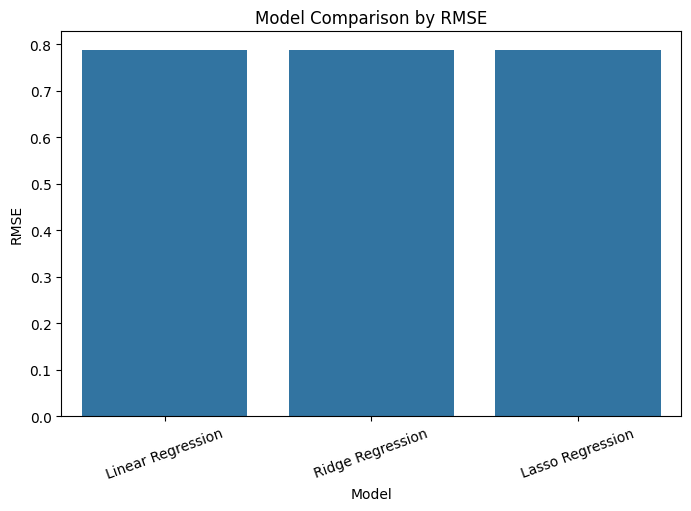

In [54]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_table,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()

<div dir="rtl" style="text-align: right;">

גרף R2

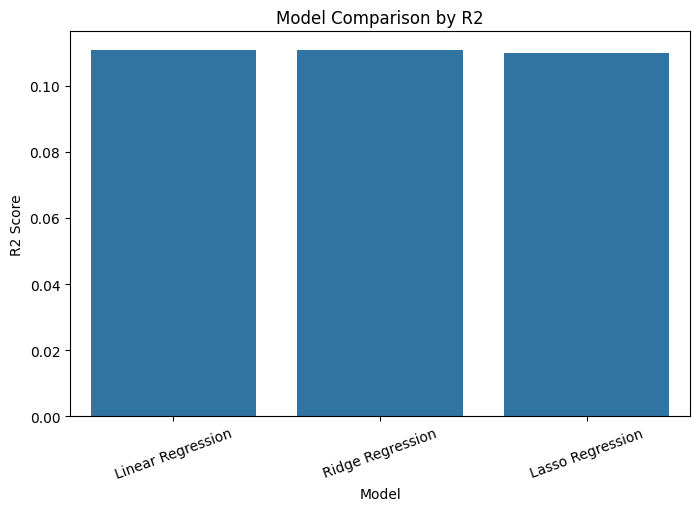

In [55]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_table,
    x="Model",
    y="R2"
)

plt.title("Model Comparison by R2")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.show()

<div dir="rtl" style="text-align: right;">

בתרגיל זה בניתי מודלי רגרסיה במטרה לחזות את הדירוג הממוצע של סרטים מתוך MovieLens.

תחילה טענתי את הנתונים מתוך קובץ ZIP, ולאחר מכן חיברתי בין טבלת הדירוגים לטבלת הסרטים לפי movieId.
עמודת timestamp הומרה לתאריך, ומתוכה חולצו שנה וחודש.
לאחר מכן ביצעתי אגרגציה לרמת הסרט: חישבתי דירוג ממוצע לכל סרט, מספר דירוגים, ומאפייני זמן.
בנוסף, המרתי את עמודת הז׳אנרים למשתני dummy.

נבנו שלושה מודלים:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression

המודלים הוערכו באמצעות R2 ו־RMSE.
Ridge ו־Lasso מוסיפים רגולריזציה, ולכן יכולים לעזור בצמצום overfitting ובשליטה על השפעת פיצ׳רים פחות חשובים.

מניתוח המקדמים ניתן לראות אילו מאפיינים משפיעים יותר על הדירוג הממוצע.
ז׳אנרים מסוימים ומספר הדירוגים הם מאפיינים שיכולים להשפיע על התחזית.
בנוסף, Lasso מאפשר לזהות פיצ׳רים פחות חשובים על ידי איפוס מקדמים.

לסיכום, המודל מספק הבנה בסיסית של הקשר בין מאפייני הסרט לבין הדירוג הממוצע שלו, אך יכולת החיזוי מוגבלת משום שהפיצ׳רים יחסית פשוטים.
ניתן לשפר את המודל בהמשך באמצעות הוספת מאפייני משתמשים, חיזוי דירוגים בודדים, שימוש בעצי החלטה, או חלוקה לפי זמן.